In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#using evaluation metrics from core/evaluation.py
import sys
import os
project_root = os.path.abspath("..")
if project_root not in sys.path:
    sys.path.insert(0, project_root)
    
from core.evaluation import evaluate_strategy_full, plot_strategy_vs_buy_hold

# 1. OPTIMIZATION FUNCTION
finding out the threshold for vol ratio based on sharpe ratio and max drawdown. 
problem with it is it might be overfitting, can consider modify it when doing rolling window.

In [ ]:
def find_best_thresholds(macd_path, boll_path, trend_space=None, range_space=None):
    """
    Performs grid search to find the optimal vol-filter thresholds.
    Balances Sharpe Ratio against Maximum Drawdown.
    """
    # Load and merge
    macd_df = pd.read_csv(macd_path)
    boll_df = pd.read_csv(boll_path)
    macd_df['date'] = pd.to_datetime(macd_df['date'])
    boll_df['date'] = pd.to_datetime(boll_df['date'])
    
    df = pd.merge(macd_df[['date', 'price', 'log_return', 'position']], 
                  boll_df[['date', 'position']], 
                  on='date', suffixes=('_macd', '_boll'))
    
    # Pre-calculate common indicators
    df['vol_ratio'] = df['log_return'].rolling(30).std() / df['log_return'].rolling(90).std()
    df['sma_slope'] = df['price'].rolling(20).mean().diff()
    df = df.dropna().reset_index(drop=True)
    
    # Define ranges to test (as seen in vol_filter_bestthreshold_test.ipynb)
    if trend_space is None: trend_space = np.arange(0.9, 1.4, 0.05)
    if range_space is None: range_space = np.arange(0.5, 0.9, 0.05)
    
    results = []
    
    for tt in trend_space:
        for rt in range_space:
            if rt >= tt: continue # Hysteresis constraint
            
            # Fast Regime calculation with Hysteresis
            regimes = []
            curr = 'Trend'
            for ratio in df['vol_ratio']:
                if ratio > tt: curr = 'Trend'
                elif ratio < rt: curr = 'Range'
                regimes.append(curr)
            
            # Vectorized Position logic
            temp_df = df.copy()
            temp_df['position'] = np.where(np.array(regimes) == 'Trend', 
                                           temp_df['position_macd'], 
                                           temp_df['position_boll'])
            
            # SMA Slope Filter for Bollinger
            temp_df.loc[(np.array(regimes) == 'Range') & 
                        (temp_df['position_boll'] == 1) & 
                        (temp_df['sma_slope'] < 0), 'position'] = 0
            
            # Evaluate
            _, _, summary = evaluate_strategy_full(temp_df, fee=0.001, rf_annual=0.03)
            
            # Extract metrics
            sharpe = summary.get('Sharpe Ratio', summary.get('sharpe_ratio_rf_3pct', 0))
            mdd = abs(summary.get('Max Drawdown', summary.get('max_drawdown', 0)))
            
            results.append({
                'trend_t': round(tt, 2), 
                'range_t': round(rt, 2), 
                'sharpe': sharpe, 
                'mdd': mdd,
                'score': sharpe / (mdd + 1e-6) # Balanced Score
            })

    results_df = pd.DataFrame(results).sort_values('score', ascending=False)
    return results_df



# 2. FINAL PROCESSING FUNCTION
vol_ratio : 30day sd/ 90day sd
additional rule: prevent long in bollinger when 20day SMA (simple moving average) slope is negative (see a downward trend and refuses to buy)

In [ ]:
def process_vol_filter_strategy(macd_path, boll_path, output_csv, trend_t, range_t):
    """
    Outputs the final post-trade table with strategy source column.
    """
    macd_df = pd.read_csv(macd_path)
    boll_df = pd.read_csv(boll_path)
    macd_df['date'] = pd.to_datetime(macd_df['date'])
    boll_df['date'] = pd.to_datetime(boll_df['date'])
    
    df = pd.merge(macd_df[['date', 'price', 'log_return', 'position']], 
                  boll_df[['date', 'position']], 
                  on='date', suffixes=('_macd', '_boll'))
    
    df['vol_ratio'] = df['log_return'].rolling(30).std() / df['log_return'].rolling(90).std()
    df['sma_slope'] = df['price'].rolling(20).mean().diff()
    
    # Calculate Regime with Hysteresis
    regimes, current = [], 'Trend'
    for val in df['vol_ratio']:
        if val > trend_t: current = 'Trend'
        elif val < range_t: current = 'Range'
        regimes.append(current)
    df['regime'] = regimes
    
    # Source Tracking & Position Logic
    def apply_rules(row):
        if row['regime'] == 'Trend':
            return row['position_macd'], 'macd'
        else:
            if row['position_boll'] == 1 and row['sma_slope'] < 0:
                return 0, 'neutral'
            return row['position_boll'], 'bolling'
            
    res = df.apply(apply_rules, axis=1)
    df['position'] = [x[0] for x in res]
    df['strategy_source'] = [x[1] for x in res]
    
    # Re-generate trade actions
    df['trade'] = df['position'].diff().fillna(0).astype(int)
    df['trade_action'] = df['trade'].map({1: 'buy', -1: 'sell', 0: 'hold'})
    
    # Save output
    output_cols = ['date', 'price', 'log_return', 'trade', 'trade_action', 'position', 'strategy_source']
    df[output_cols].to_csv(output_csv, index=False)
    return df

# 3. RUN EXECUTION


Optimizing thresholds...
Best Trend Thresh: 1.05, Best Range Thresh: 0.5

--- Final Strategy Performance ---
cumulative_pnl: 10.9606
average_daily_pnl: 0.0013
max_drawdown: -0.6044
annualised_return: 0.3636
sharpe_ratio_rf_3pct: 0.7701
daily_std_dev: 0.0307
annualised_volatility: 0.5866
exposure_rate: 0.4991
total_turnover: 139.0000
number_of_trades_total: 70.0000
number_of_complete_trades: 69.0000
win_rate: 0.4348
average_trade_return: 0.0637
median_trade_return: -0.0246
average_win_return: 0.2823
average_loss_return: -0.1045
profit_factor: 2.0785
payoff_ratio: 2.7021
expectancy_per_trade: 0.0637
best_trade: 0.8243
worst_trade: -0.3800
average_holding_periods: 20.6812
median_holding_periods: 19.0000
long_trades: 62.0000
short_trades: 7.0000


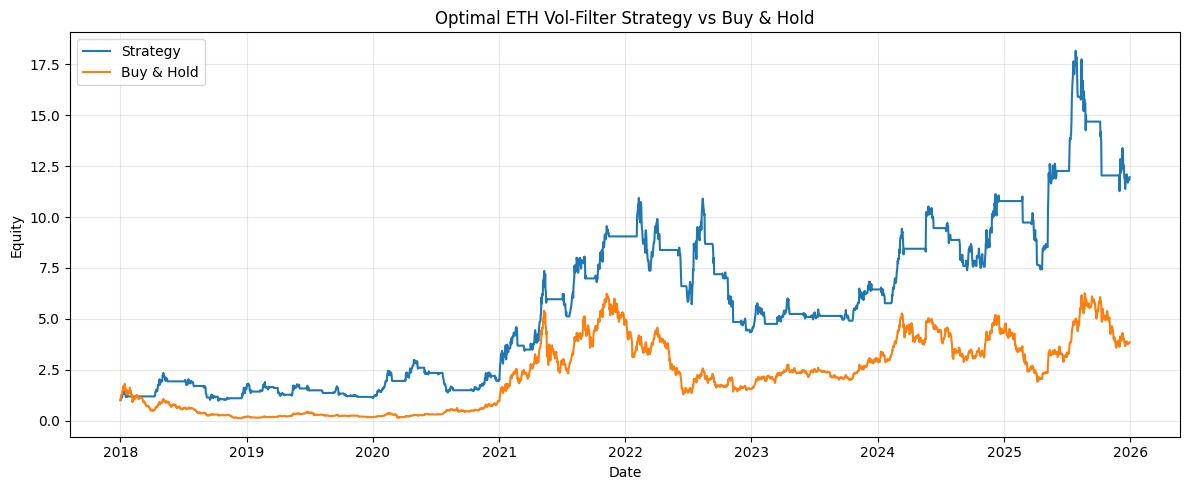

In [ ]:
# Step 1: Find best parameters
print("Optimizing thresholds...")
optimization_results = find_best_thresholds(
    '../datasets/eth_macd_18_50_13_post_trade_table.csv', 
    '../datasets/eth_bollinger_post_trade_table.csv'
)

# Step 2: Use the best performing thresholds
best_params = optimization_results.iloc[0]
print(f"Best Trend Thresh: {best_params['trend_t']}, Best Range Thresh: {best_params['range_t']}")

# Step 3: Process and Export final CSV
final_df = process_vol_filter_strategy(
    macd_path='../datasets/eth_macd_18_50_13_post_trade_table.csv',
    boll_path='../datasets/eth_bollinger_post_trade_table.csv',
    output_csv='../datasets/eth_vol_filter_post_trade.csv',
    trend_t=best_params['trend_t'],
    range_t=best_params['range_t']
)

# Step 4: Final Evaluation
daily_eval, trade_log, summary = evaluate_strategy_full(final_df, fee=0.00, rf_annual=0.03)
print("\n--- Final Strategy Performance ---")

for k, v in summary.items():
    print(f"{k}: {v:.4f}")

plot_strategy_vs_buy_hold(daily_eval, title="Optimal ETH Vol-Filter Strategy vs Buy & Hold")
plt.show()

#### run execution with btc

Optimizing thresholds...
Best Trend Thresh: 0.95, Best Range Thresh: 0.55

--- Final Strategy Performance ---
cumulative_pnl: 4.3988
average_daily_pnl: 0.0008
max_drawdown: -0.6968
annualised_return: 0.2345
sharpe_ratio_rf_3pct: 0.6284
daily_std_dev: 0.0232
annualised_volatility: 0.4436
exposure_rate: 0.4923
total_turnover: 155.0000
number_of_trades_total: 78.0000
number_of_complete_trades: 77.0000
win_rate: 0.4545
average_trade_return: 0.0365
median_trade_return: -0.0131
average_win_return: 0.1751
average_loss_return: -0.0791
profit_factor: 1.8457
payoff_ratio: 2.2149
expectancy_per_trade: 0.0365
best_trade: 0.5864
worst_trade: -0.2768
average_holding_periods: 18.2597
median_holding_periods: 17.0000
long_trades: 70.0000
short_trades: 7.0000


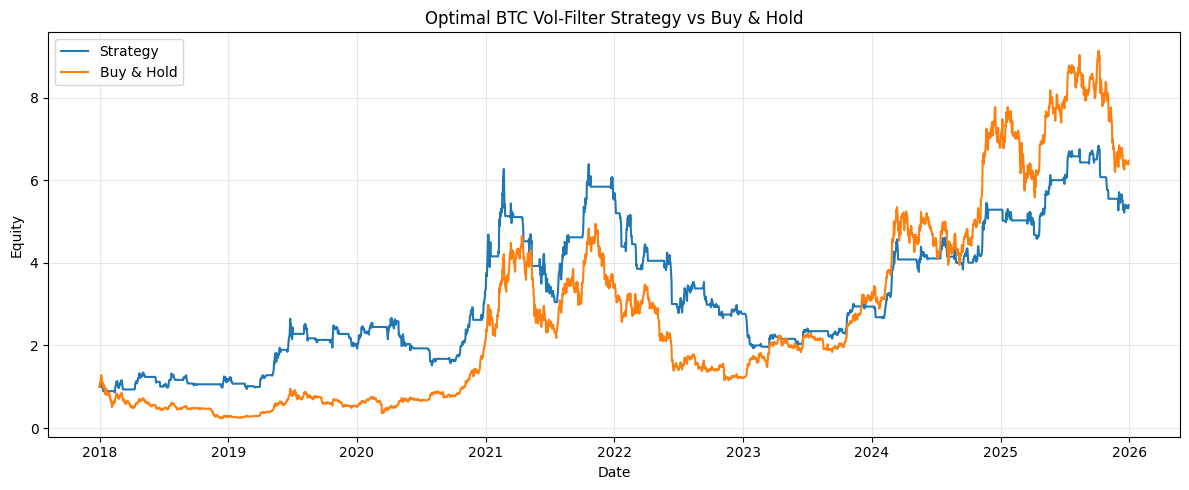

In [ ]:
# Step 1: Find best parameters
print("Optimizing thresholds...")
optimization_results = find_best_thresholds(
    '../datasets/btc_macd_16_20_15_post_trade_table.csv',
    '../datasets/btc_bollinger_post_trade_table.csv'
)

# Step 2: Use the best performing thresholds
best_params = optimization_results.iloc[0]
print(f"Best Trend Thresh: {best_params['trend_t']}, Best Range Thresh: {best_params['range_t']}")

# Step 3: Process and Export final CSV
final_df = process_vol_filter_strategy(
    macd_path='../datasets/btc_macd_16_20_15_post_trade_table.csv',
    boll_path='../datasets/btc_bollinger_post_trade_table.csv',
    output_csv='../datasets/btc_vol_filter_post_trade.csv',
    trend_t=best_params['trend_t'],
    range_t=best_params['range_t']
)

# Step 4: Final Evaluation
daily_eval, trade_log, summary = evaluate_strategy_full(final_df, fee=0.00, rf_annual=0.03)
print("\n--- Final Strategy Performance ---")

for k, v in summary.items():
    print(f"{k}: {v:.4f}")

plot_strategy_vs_buy_hold(daily_eval, title="Optimal BTC Vol-Filter Strategy vs Buy & Hold")
plt.show()

# 4. STRATEGY COMPARISON
Evaluate Bollinger, MACD, and Vol-Filter (Adaptive) side-by-side for ETH and BTC.

In [ ]:
# =========================
# ETH — isolate component strategies
# =========================

# Re-run final_df for ETH
eth_macd_df = pd.read_csv('../datasets/eth_macd_18_50_13_post_trade_table.csv')
eth_boll_df = pd.read_csv('../datasets/eth_bollinger_post_trade_table.csv')
eth_macd_df['date'] = pd.to_datetime(eth_macd_df['date'])
eth_boll_df['date'] = pd.to_datetime(eth_boll_df['date'])

eth_macd_only = pd.merge(
    eth_macd_df[['date', 'price', 'log_return', 'position']],
    eth_boll_df[['date', 'position']],
    on='date', suffixes=('_macd', '_boll')
).rename(columns={'position_macd': 'position'})
eth_macd_only = eth_macd_only.drop(columns=['position_boll'])
eth_macd_only['trade'] = eth_macd_only['position'].diff().fillna(0).clip(-1, 1)

eth_boll_only = pd.merge(
    eth_macd_df[['date', 'price', 'log_return', 'position']],
    eth_boll_df[['date', 'position']],
    on='date', suffixes=('_macd', '_boll')
).rename(columns={'position_boll': 'position'})
eth_boll_only = eth_boll_only.drop(columns=['position_macd'])
eth_boll_only['trade'] = eth_boll_only['position'].diff().fillna(0).clip(-1, 1)

# Re-run ETH vol-filter with best params
eth_optimization_results = find_best_thresholds(
    '../datasets/eth_macd_18_50_13_post_trade_table.csv',
    '../datasets/eth_bollinger_post_trade_table.csv'
)
eth_best = eth_optimization_results.iloc[0]
eth_final_df = process_vol_filter_strategy(
    macd_path='../datasets/eth_macd_18_50_13_post_trade_table.csv',
    boll_path='../datasets/eth_bollinger_post_trade_table.csv',
    output_csv='../datasets/eth_vol_filter_post_trade.csv',
    trend_t=eth_best['trend_t'],
    range_t=eth_best['range_t']
)

eth_adaptive_eval, _, eth_adaptive_summary = evaluate_strategy_full(eth_final_df, fee=0.0, rf_annual=0.03)
eth_macd_eval,    _, eth_macd_summary    = evaluate_strategy_full(eth_macd_only,  fee=0.0, rf_annual=0.03)
eth_boll_eval,    _, eth_boll_summary    = evaluate_strategy_full(eth_boll_only,  fee=0.0, rf_annual=0.03)


In [ ]:
# =========================
# BTC — isolate component strategies
# =========================

btc_macd_df = pd.read_csv('../datasets/btc_macd_16_20_15_post_trade_table.csv')
btc_boll_df = pd.read_csv('../datasets/btc_bollinger_post_trade_table.csv')
btc_macd_df['date'] = pd.to_datetime(btc_macd_df['date'])
btc_boll_df['date'] = pd.to_datetime(btc_boll_df['date'])

btc_macd_only = pd.merge(
    btc_macd_df[['date', 'price', 'log_return', 'position']],
    btc_boll_df[['date', 'position']],
    on='date', suffixes=('_macd', '_boll')
).rename(columns={'position_macd': 'position'})
btc_macd_only = btc_macd_only.drop(columns=['position_boll'])
btc_macd_only['trade'] = btc_macd_only['position'].diff().fillna(0).clip(-1, 1)

btc_boll_only = pd.merge(
    btc_macd_df[['date', 'price', 'log_return', 'position']],
    btc_boll_df[['date', 'position']],
    on='date', suffixes=('_macd', '_boll')
).rename(columns={'position_boll': 'position'})
btc_boll_only = btc_boll_only.drop(columns=['position_macd'])
btc_boll_only['trade'] = btc_boll_only['position'].diff().fillna(0).clip(-1, 1)

# Re-run BTC vol-filter with best params
btc_optimization_results = find_best_thresholds(
    '../datasets/btc_macd_16_20_15_post_trade_table.csv',
    '../datasets/btc_bollinger_post_trade_table.csv'
)
btc_best = btc_optimization_results.iloc[0]
btc_final_df = process_vol_filter_strategy(
    macd_path='../datasets/btc_macd_16_20_15_post_trade_table.csv',
    boll_path='../datasets/btc_bollinger_post_trade_table.csv',
    output_csv='../datasets/btc_vol_filter_post_trade.csv',
    trend_t=btc_best['trend_t'],
    range_t=btc_best['range_t']
)

btc_adaptive_eval, _, btc_adaptive_summary = evaluate_strategy_full(btc_final_df, fee=0.0, rf_annual=0.03)
btc_macd_eval,    _, btc_macd_summary    = evaluate_strategy_full(btc_macd_only,  fee=0.0, rf_annual=0.03)
btc_boll_eval,    _, btc_boll_summary    = evaluate_strategy_full(btc_boll_only,  fee=0.0, rf_annual=0.03)


In [ ]:
cols = [
    "cumulative_pnl",
    "average_daily_pnl",
    "max_drawdown",
    "annualised_return",
    "sharpe_ratio_rf_3pct",
    "annualised_volatility"
]


In [ ]:
btc_compare = pd.concat([
    pd.DataFrame([btc_adaptive_summary], index=["Vol-Filter (Adaptive)"]),
    pd.DataFrame([btc_macd_summary],     index=["MACD"]),
    pd.DataFrame([btc_boll_summary],     index=["Bollinger"]),
])[cols]

btc_compare


,cumulative_pnl,average_daily_pnl,max_drawdown,annualised_return,sharpe_ratio_rf_3pct,annualised_volatility
Vol-Filter (Adaptive),4.398761,0.000845,-0.696761,0.234541,0.628422,0.443635
MACD,20.947787,0.001327,-0.563726,0.471013,1.021047,0.445369
Bollinger,-0.999997,-0.003923,-0.999997,-0.792390,-2.852977,0.512214


In [ ]:
eth_compare = pd.concat([
    pd.DataFrame([eth_adaptive_summary], index=["Vol-Filter (Adaptive)"]),
    pd.DataFrame([eth_macd_summary],     index=["MACD"]),
    pd.DataFrame([eth_boll_summary],     index=["Bollinger"]),
])[cols]

eth_compare


,cumulative_pnl,average_daily_pnl,max_drawdown,annualised_return,sharpe_ratio_rf_3pct,annualised_volatility
Vol-Filter (Adaptive),10.960596,0.001319,-0.604410,0.363556,0.770094,0.586583
MACD,53.419766,0.001842,-0.614735,0.647765,1.089449,0.590129
Bollinger,-1.000000,-0.005481,-1.000000,-0.895930,-2.911466,0.697227


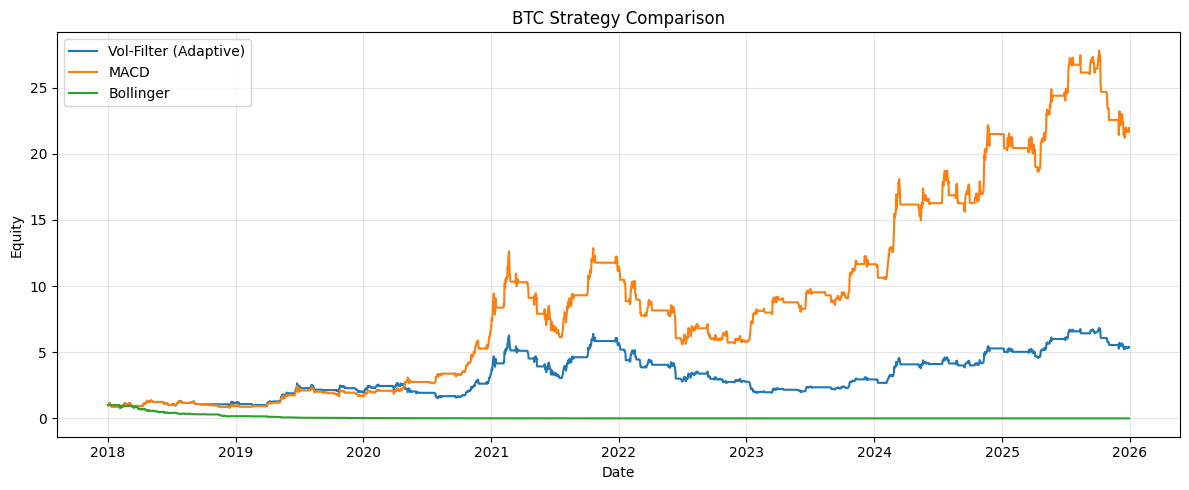

In [ ]:
plt.figure(figsize=(12, 5))
plt.plot(btc_adaptive_eval["date"], btc_adaptive_eval["equity_curve"], label="Vol-Filter (Adaptive)")
plt.plot(btc_macd_eval["date"],     btc_macd_eval["equity_curve"],     label="MACD")
plt.plot(btc_boll_eval["date"],     btc_boll_eval["equity_curve"],     label="Bollinger")
plt.legend()
plt.title("BTC Strategy Comparison")
plt.xlabel("Date")
plt.ylabel("Equity")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


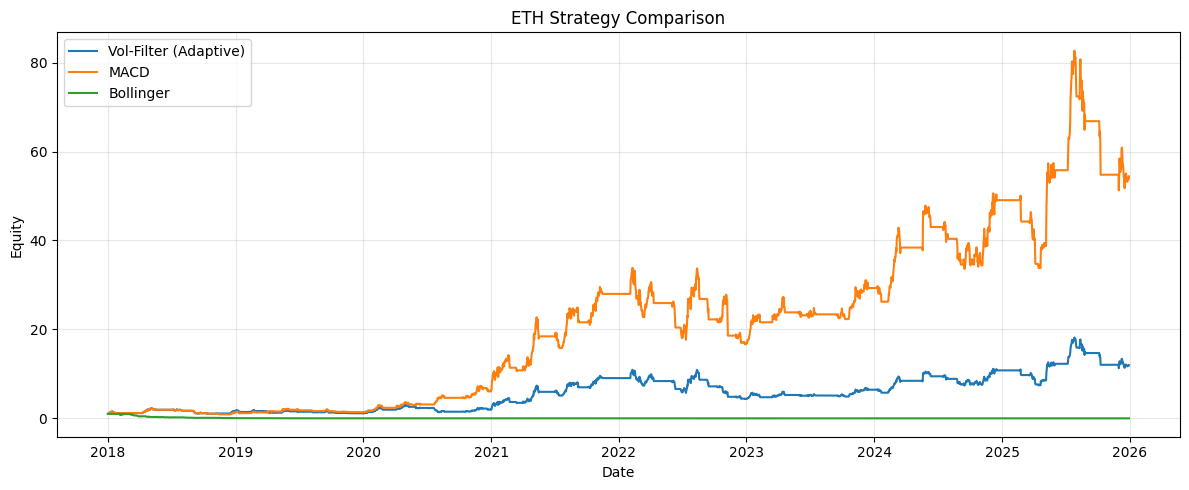

In [ ]:
plt.figure(figsize=(12, 5))
plt.plot(eth_adaptive_eval["date"], eth_adaptive_eval["equity_curve"], label="Vol-Filter (Adaptive)")
plt.plot(eth_macd_eval["date"],     eth_macd_eval["equity_curve"],     label="MACD")
plt.plot(eth_boll_eval["date"],     eth_boll_eval["equity_curve"],     label="Bollinger")
plt.legend()
plt.title("ETH Strategy Comparison")
plt.xlabel("Date")
plt.ylabel("Equity")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
